## Import / setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from get_data import (
    fetch_sector_map_with_report,
    download_binance_sector_data,
    explore_downloaded_data,
    preview_market_data,
)
from coint import (
    run_basis_cointegration_strategy,
    plot_portfolio_equity,
    optimize_basis_backtest_parameters,
    build_parameter_plateau,
    plot_parameter_plateau,
    save_strategy_result,
    load_strategy_portfolio,
)

DATABASE_PATH = Path("data")
CONFIG_PATH = Path("config/api_config.json")
N_JOBS = 2
OPTIMIZE_N_JOBS = 2
SHOW_PROGRESS = True
ROLLING_PAIRS_CACHE = DATABASE_PATH / "cache" / "rolling_basis_pairs.parquet"
ROLLING_PAIRS_PROGRESS = DATABASE_PATH / "cache" / "rolling_basis_pairs_progress.csv"
OPTIMIZATION_RESULT_PATH = DATABASE_PATH / "cache" / "basis_parameter_optimization.parquet"
OPTIMIZATION_RESULT_CSV = DATABASE_PATH / "cache" / "basis_parameter_optimization.csv"
STRATEGY_RESULT_DIR = Path("..") / "aggregate" / "results" / "cointegration_basis"

FORMATION_WINDOW = "60D"
TRADING_WINDOW = "30D"
SCAN_STEP = "30D"
PREFILTER_TOP_PAIRS_PER_SECTOR = 200

ENTRY_Z = 2.0
EXIT_Z = 0.5
FEE_RATE = 0.0004
STOP_LOSS_RETURN = -0.02
STOP_LOSS_Z = 3.5

START_DATE = datetime(2020, 1, 1)
END_DATE = datetime(2026, 5, 26)

## Data

### Fetch Sector Classification


In [ ]:
try:
    fetch_sector_map_with_report(
        base_path=DATABASE_PATH,
        categories_to_process=("spot", "linear"),
        sleep_seconds=0.5,
    )
except ImportError as e:
    print(e)
except Exception as e:
    print(f"獲取行業映射出錯: {e}")

### Download Binance Sector Data


In [ ]:
skip_sectors = ["USD Stablecoin", "Fiat-backed Stablecoin"]

try:
    binance_universe = download_binance_sector_data(
        base_path=DATABASE_PATH,
        start_date=START_DATE,
        end_date=END_DATE,
        skip_sectors=skip_sectors,
        interval="1h",
        sleep_seconds=0.5,
        include_funding_rate=False,
    )
except Exception as e:
    print(f"下載過程中出錯: {e}")

### Data Exploration and Validation


In [ ]:
data_summaries = explore_downloaded_data(DATABASE_PATH)

### Preview Parquet Data


In [ ]:
preview_market_data(DATABASE_PATH)

## Analysis

### basic signal

,basis_rows,basis_symbols,funding_rows,funding_symbols,sectors,rolling_pairs,backtested_pair_windows,trades
0,56075,192,14970,191,8,1627,760,21173


,value
total_return,-0.337080
annual_return,-0.063783
annual_volatility,0.028248
sharpe,-2.258017
max_drawdown,-0.630205
trades,21173.000000
win_rate,0.689227
avg_active_pairs,10.000000


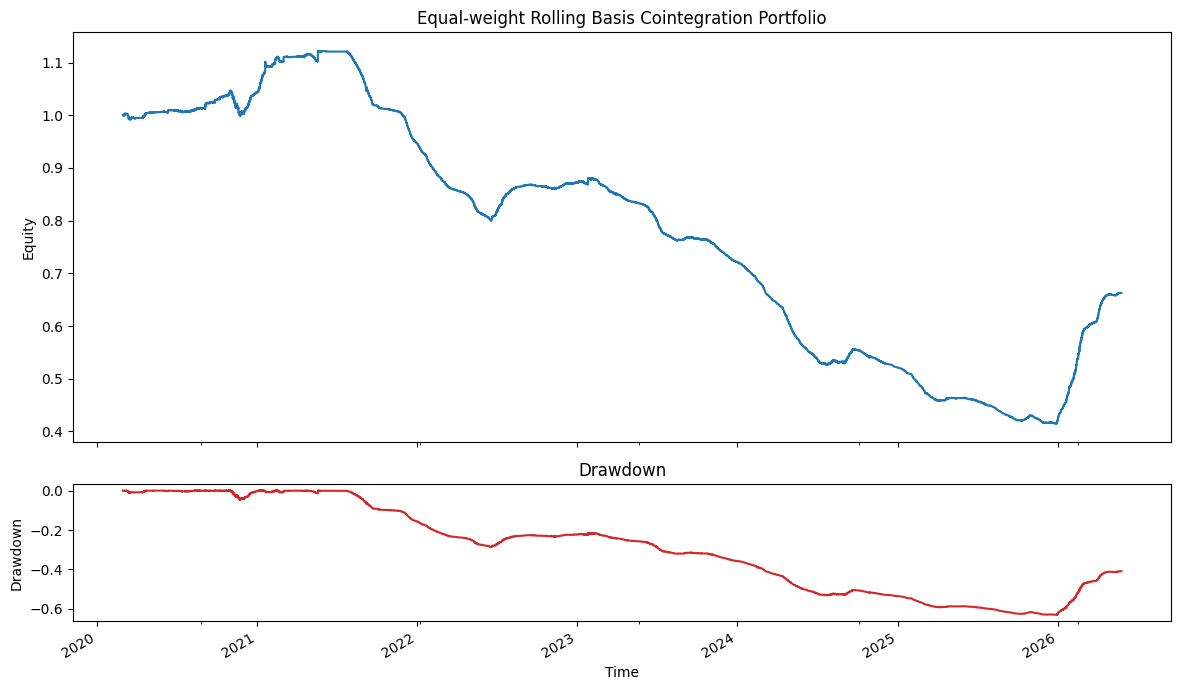

In [2]:
result = run_basis_cointegration_strategy(
    database_path=DATABASE_PATH,
    cache_path=ROLLING_PAIRS_CACHE,
    progress_path=ROLLING_PAIRS_PROGRESS,
    formation_window=FORMATION_WINDOW,
    trading_window=TRADING_WINDOW,
    step=SCAN_STEP,
    prefilter_top_pairs_per_sector=PREFILTER_TOP_PAIRS_PER_SECTOR,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    fee_rate=FEE_RATE,
    stop_loss_return=STOP_LOSS_RETURN,
    stop_loss_z=STOP_LOSS_Z,
    n_jobs=N_JOBS,
    show_progress=SHOW_PROGRESS,
)

display(result["data_summary"])
display(result["summary_table"])

if not result["portfolio"].empty:
    plot_portfolio_equity(result["portfolio"])

### optimize

In [ ]:
entry_z_values = np.arange(1.5, 3.1, 0.25)
exit_z_values = np.arange(0.25, 0.81, 0.05)

param_grid = [
    {
        "entry_z": round(float(entry_z), 4),
        "exit_z": round(float(exit_z), 4),
        "stop_loss_return": stop_loss_return,
        "stop_loss_z": stop_loss_z,
    }
    for entry_z in entry_z_values
    for exit_z in exit_z_values
    for stop_loss_return in [-0.01, -0.02, None]
    for stop_loss_z in [3.0, 3.5, None]
]

optimization = optimize_basis_backtest_parameters(
    database_path=DATABASE_PATH,
    rolling_pairs_path=ROLLING_PAIRS_CACHE,
    param_grid=param_grid,
    max_pairs_per_window=10,
    fee_rate=FEE_RATE,
    n_jobs=OPTIMIZE_N_JOBS,
    existing_results_path=OPTIMIZATION_RESULT_PATH,
    save_results_path=OPTIMIZATION_RESULT_PATH,
    save_results_csv_path=OPTIMIZATION_RESULT_CSV,
    show_progress=SHOW_PROGRESS,
)

optimization_filtered = optimization.query(
    "trades >= 30 and max_drawdown > -0.3 and avg_active_pairs >= 1"
)

### parameter plateau


exit_z,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80
entry_z,,,,,,,,,,,,
1.50,-3.747019,-4.235106,-4.758781,-5.278003,-5.806170,-6.312238,-6.824840,-7.363906,-7.826233,-8.265688,-8.715448,-9.175971
1.75,-0.434445,-0.818791,-1.237355,-1.662837,-2.072061,-2.492372,-2.908850,-3.363936,-3.722868,-4.113617,-4.530171,-4.937520
2.00,1.848294,1.571022,1.263177,0.989526,0.693762,0.391615,0.107995,-0.234251,-0.502162,-0.775223,-1.105503,-1.432208
2.25,2.936473,2.735246,2.539618,2.364538,2.161627,1.961452,1.763912,1.528097,1.342168,1.155574,0.911093,0.690534
2.50,3.042538,2.905948,2.791037,2.674819,2.562413,2.457834,2.347975,2.220516,2.093831,2.005107,1.843089,1.715242
2.75,3.076452,2.997358,2.928394,2.836333,2.767636,2.701694,2.626189,2.536787,2.443302,2.401485,2.311463,2.217422
3.00,2.893021,2.848504,2.791962,2.728447,2.690404,2.637805,2.594960,2.539545,2.483410,2.462585,2.398338,2.349254


,entry_z,exit_z,median_sharpe,mean_return,worst_drawdown,sharpe_std,runs,plateau_score
0,2.75,0.25,3.076452,0.817525,-0.035337,NaN,1,3.076452
1,2.50,0.25,3.042538,0.863759,-0.070482,NaN,1,3.042538
2,2.75,0.30,2.997358,0.785023,-0.036860,NaN,1,2.997358
3,2.25,0.25,2.936473,0.798042,-0.182241,NaN,1,2.936473
4,2.75,0.35,2.928394,0.758811,-0.038599,NaN,1,2.928394
5,2.50,0.30,2.905948,0.809405,-0.076894,NaN,1,2.905948
6,3.00,0.25,2.893021,0.710875,-0.020944,NaN,1,2.893021
7,3.00,0.30,2.848504,0.693115,-0.020944,NaN,1,2.848504
8,2.75,0.40,2.836333,0.725367,-0.040043,NaN,1,2.836333
9,3.00,0.35,2.791962,0.673478,-0.020944,NaN,1,2.791962


(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': "sharpe plateau | target={'stop_loss_return': None, 'stop_loss_z': None}"}, xlabel='exit_z', ylabel='entry_z'>)

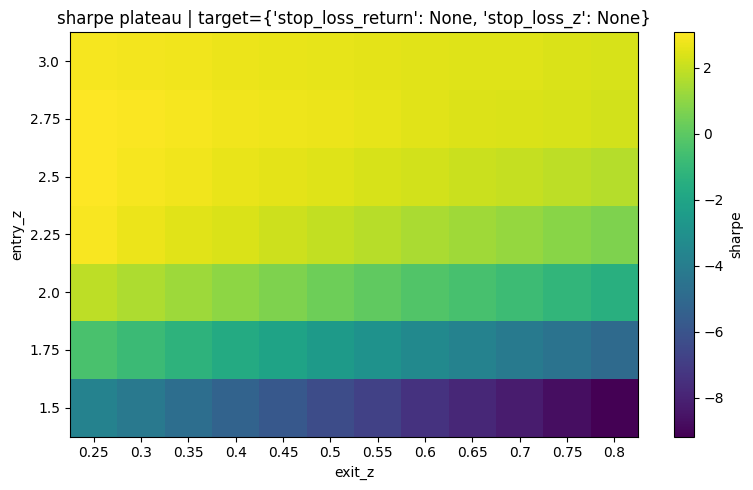

In [2]:
optimization = pd.read_parquet(OPTIMIZATION_RESULT_PATH)

PLATEAU_METRIC = "sharpe"
PLATEAU_X = "exit_z"
PLATEAU_Y = "entry_z"
PLATEAU_USE_FILTERED = False
PLATEAU_TARGET = {
    "stop_loss_return": None,
    "stop_loss_z": None,
}

plateau_slice, plateau_table, plateau_rank = build_parameter_plateau(
    optimization=optimization,
    metric=PLATEAU_METRIC,
    x=PLATEAU_X,
    y=PLATEAU_Y,
    target=PLATEAU_TARGET,
    use_filtered=PLATEAU_USE_FILTERED,
)

display(plateau_table)
display(plateau_rank.head(20))
plot_parameter_plateau(
    plateau_table,
    metric=PLATEAU_METRIC,
    x=PLATEAU_X,
    y=PLATEAU_Y,
    target=PLATEAU_TARGET,
)

### backtest & save

,basis_rows,basis_symbols,funding_rows,funding_symbols,sectors,rolling_pairs,backtested_pair_windows,trades
0,56075,192,14970,191,8,1627,760,5596


,total_return,annual_return,annual_volatility,sharpe,max_drawdown,trades,win_rate,avg_active_pairs
value,0.817525,0.100526,0.032676,3.076452,-0.035337,5596.0,0.870979,10.0


{'portfolio': WindowsPath('../aggregate/results/cointegration_basis/portfolio.parquet'),
 'trading_log': WindowsPath('../aggregate/results/cointegration_basis/trading_log.parquet'),
 'summary': WindowsPath('../aggregate/results/cointegration_basis/summary.csv'),
 'rolling_pairs': WindowsPath('../aggregate/results/cointegration_basis/rolling_pairs.parquet'),
 'config': WindowsPath('../aggregate/results/cointegration_basis/config.json'),
 'manifest': WindowsPath('../aggregate/results/cointegration_basis/manifest.json')}

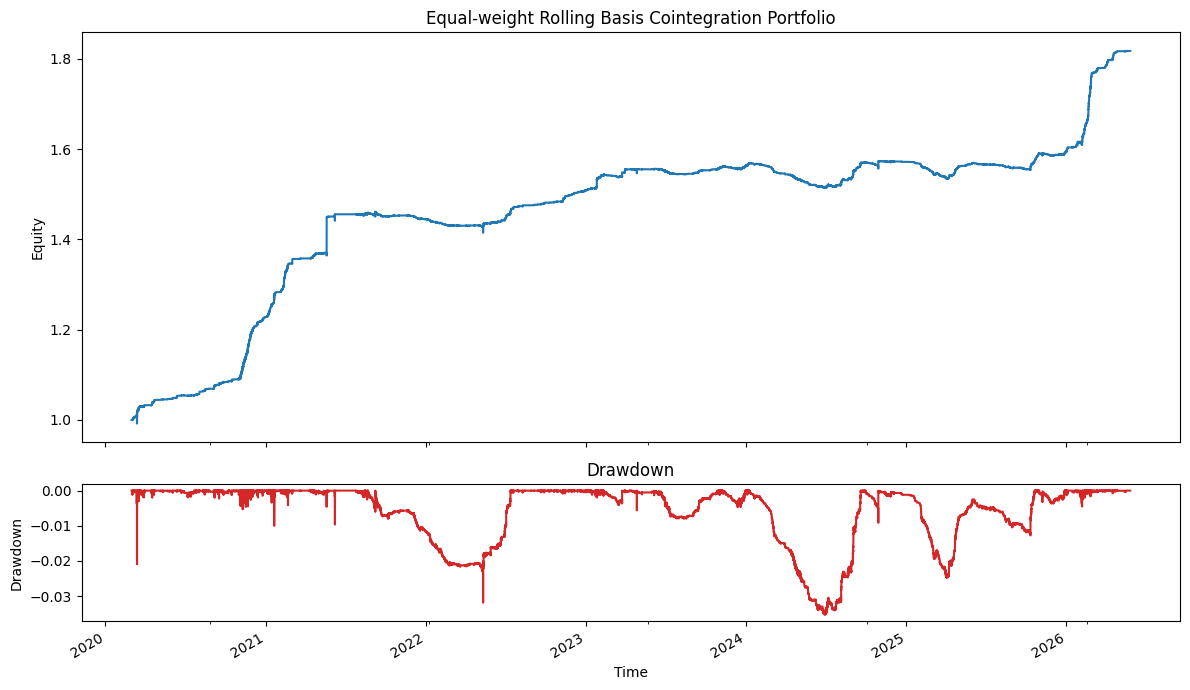

In [3]:
NEW_ENTRY_Z = 2.75
NEW_EXIT_Z = 0.25
NEW_STOP_LOSS_RETURN = None
NEW_STOP_LOSS_Z = None

new_result = run_basis_cointegration_strategy(
    database_path=DATABASE_PATH,
    cache_path=ROLLING_PAIRS_CACHE,
    progress_path=ROLLING_PAIRS_PROGRESS,
    formation_window=FORMATION_WINDOW,
    trading_window=TRADING_WINDOW,
    step=SCAN_STEP,
    prefilter_top_pairs_per_sector=PREFILTER_TOP_PAIRS_PER_SECTOR,
    entry_z=NEW_ENTRY_Z,
    exit_z=NEW_EXIT_Z,
    fee_rate=FEE_RATE,
    stop_loss_return=NEW_STOP_LOSS_RETURN,
    stop_loss_z=NEW_STOP_LOSS_Z,
    n_jobs=N_JOBS,
    use_cache=True,
    incremental_cache=True,
    show_progress=False,
)

display(new_result["data_summary"])
display(new_result["summary_table"].T)

if not new_result["portfolio"].empty:
    plot_portfolio_equity(new_result["portfolio"])

saved_paths = save_strategy_result(
    result=new_result,
    output_dir=STRATEGY_RESULT_DIR,
    strategy_name="cointegration_basis",
    config={
        "formation_window": FORMATION_WINDOW,
        "trading_window": TRADING_WINDOW,
        "scan_step": SCAN_STEP,
        "prefilter_top_pairs_per_sector": PREFILTER_TOP_PAIRS_PER_SECTOR,
        "entry_z": NEW_ENTRY_Z,
        "exit_z": NEW_EXIT_Z,
        "fee_rate": FEE_RATE,
        "stop_loss_return": NEW_STOP_LOSS_RETURN,
        "stop_loss_z": NEW_STOP_LOSS_Z,
    },
)
saved_paths